## ELETTRA-49: ID effects and correction (full example)

In [1]:
# In this example effects on the linear optics from different ID models are compared
# Corrections for the Radia's RK are computed using local/global (CT) and local (ORM) methods

### Import

In [2]:
# Import

import torch
from torch import Tensor

from pathlib import Path
from tqdm import tqdm

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
matplotlib.rcParams['text.usetex'] = True

from model.library.element import Element
from model.library.line import Line
from model.library.corrector import Corrector
from model.library.quadrupole import Quadrupole
from model.library.matrix import Matrix

from model.command.external import load_lattice
from model.command.build import build
from model.command.tune import tune
from model.command.tune import chromaticity
from model.command.orbit import dispersion
from model.command.orbit import ORM
from model.command.twiss import twiss
from model.command.advance import advance
from model.command.coupling import coupling

### Data type & device

In [3]:
# Set data type and device

Element.dtype = dtype = torch.float64
Element.device = device = torch.device('cpu')

### Lattice

In [4]:
# Load lattice (ELEGANT table)
# Note, lattice is allowed to have repeated elements

path = Path('elettra.lte')
data = load_lattice(path)

In [5]:
# Build and setup lattice

ring:Line = build('RING', 'ELEGANT', data)

# Flatten sublines

ring.flatten()

# Remove all marker elements but the ones starting with MLL (long straight section centers)

ring.remove_group(pattern=r'^(?!MSS_)(?!MLL_).*', kinds=['Marker'])

# Replace all sextupoles with quadrupoles

def factory(element:Element) -> None:
    table = element.serialize
    table.pop('ms', None)
    return Quadrupole(**table)

ring.replace_group(pattern=r'', factory=factory, kinds=['Sextupole'])

# Set linear dipoles

def apply(element:Element) -> None:
    element.linear = True

ring.apply(apply, kinds=['Dipole'])

# Insert correctors

for name, *_ in ring.layout():
    if name.startswith('CH'):
        corrector = Corrector(f'{name}_CXY', factor=1)
        ring.split((1 + 1, None, [name], None), paste=[corrector])

# Merge drifts

ring.merge()

# Change lattice start start

ring.start = "BPM_S01_01"

# Split BPMs

ring.split((None, ['BPM'], None, None))

# Roll lattice

ring.roll(1)

# Splice

ring.splice()

# Describe

ring.describe

{'BPM': 168,
 'Drift': 744,
 'Dipole': 156,
 'Quadrupole': 360,
 'Corrector': 24,
 'Marker': 24}

### Optics (nominal)

In [6]:
# Compute tunes (fractional part)

nux, nuy = tune(ring, [], matched=True, limit=1)

In [7]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype, device=device)
etaqx, etapx, etaqy, etapy = dispersion(ring, orbit, [], limit=1)

In [8]:
# Compute twiss parameters

ax, bx, ay, by = twiss(ring, [], matched=True, advance=True, full=False).T

In [9]:
# Compute phase advances

mux, muy = advance(ring, [], alignment=False, matched=True).T

In [10]:
# Compute coupling

c = coupling(ring, [])

In [11]:
# Compute chromaticity

psi = chromaticity(ring, [])

### Response matrices

In [12]:
# Quadrupole names for global tune correction

nqf = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
nqd = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

In [13]:
# Define tune observable

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(nqf)*[kf] + len(nqd)*[kd])
    return tune(ring, [kn], ('kn', None, nqf + nqd, None), matched=True, limit=1)

In [14]:
# Compute tune jacobian

knobs = torch.tensor([0.0, 0.0], dtype=dtype, device=device)
global_target = global_observable(knobs)
global_matrix = torch.func.jacrev(global_observable)(knobs)

print(global_target)
print(global_matrix)

tensor([0.2994, 0.1608], dtype=torch.float64)
tensor([[ 5.8543,  2.0964],
        [-2.9918, -1.2602]], dtype=torch.float64)


In [15]:
# Local knobs dictionary

table_nkn = {f'S{i:02}': [f'OCT_S{i:02}_02', f'QF_S{i:02}_02', f'QD_S{i:02}_02', f'QD_S{i:02}_03', f'QF_S{i:02}_03', f'OCT_S{i:02}_03'] for i in range(1, 12 + 1)}
table_nks = {f'S{i:02}': [f'SD_S{i:02}_05', f'SH_S{i:02}_02', f'SH_S{i:02}_03', f'SD_S{i:02}_06'] for i in range(1, 12 + 1)}

In [16]:
# Define coupled twiss observable

def observable_twiss(kn, ks, nkn, nks):
    return twiss(ring, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), matched=True, advance=True, full=False, convert=False)

In [17]:
# Define dispersion observable

def observable_dispersion(kn, ks, nkn, nks):  
    orbit = torch.tensor(4*[0.0], dtype=dtype, device=device)
    etax, _, etay, _ = dispersion(ring, orbit, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None))
    return torch.stack([etax, etay]).T

In [18]:
# Define local & global observable

def observable(knobs, nkn, nks):
    kn, ks = torch.split(knobs, [6, 4])  
    betas = observable_twiss(kn, ks, nkn, nks)
    etas = observable_dispersion(kn, ks, nkn, nks)
    return torch.cat([betas.flatten(), etas.flatten()])

In [19]:
# Compute local & global jacobians 

knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype, device=device)
sections = [f'S{i:02}' for i in range(1, 12 + 1)]

ts_twiss = dict.fromkeys(sections)
ms_twiss = dict.fromkeys(sections)

for section in tqdm(sections):
    ts_twiss[section] = observable(knobs, table_nkn[section], table_nks[section])
    ms_twiss[section] = torch.func.jacfwd(observable)(knobs, table_nkn[section], table_nks[section])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [11:48<00:00, 59.08s/it]


In [20]:
# Define ORM observable

def observable_orm(kn, ks, nkn, nks):  
    orm = ORM(ring, orbit,  [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), limit=1)
    return orm

In [21]:
# Define local observable

def observable(knobs, nkn, nks):
    kn, ks = torch.split(knobs, [6, 4])  
    orm = observable_orm(kn, ks, nkn, nks)
    return orm.flatten()

In [22]:
# Compute local jacobians 

knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype, device=device)
sections = [f'S{i:02}' for i in range(1, 12 + 1)]

ts_orbit = dict.fromkeys(sections)
ms_orbit = dict.fromkeys(sections)

for section in tqdm(sections):
    ts_orbit[section] = observable(knobs, table_nkn[section], table_nks[section])
    ms_orbit[section] = torch.func.jacfwd(observable)(knobs, table_nkn[section], table_nks[section])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [03:05<00:00, 15.45s/it]


In [23]:
# Define correction containers

correction_twiss = dict.fromkeys(sections)
correction_orbit = dict.fromkeys(sections)

### ID

In [24]:
# EU100_L01 (GAP=19)

# Define ID transport matrices

# 1K -- Elleaume's potential (single kick for the whole ID)
# NK -- Elleaume's potential (one kick per ID period)
# RK -- Radia's RK

A1K = [[-0.0336671, 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0.0585246, 0.],
       [0., 0., 0., 0.]]

ANK = [[-0.0344386, 0., 0., 0.],
       [0., -0.0445673, 0., 0.],
       [0., 0., 0.056303, 0.],
       [0., 0., 0., 0.0804237]]

ARK = [[-0.0348424, 0., 0., 0.00159233],
       [0., -0.0460831, 0.00177914, 0.],
       [0., 0.00177914, 0.0568538, 0.],
       [0.00159233, 0., 0., 0.0831168]]

A1K = torch.tensor(A1K, dtype=dtype)
ANK = torch.tensor(ANK, dtype=dtype)
ARK = torch.tensor(ARK, dtype=dtype)

CENTER = 0.0

ID_1K = Matrix('ID', length=0.0, A=A1K[torch.triu(torch.ones_like(A1K, dtype=torch.bool))].tolist())
ID_NK = Matrix('ID', length=0.0, A=ANK[torch.triu(torch.ones_like(ANK, dtype=torch.bool))].tolist())
ID_RK = Matrix('ID', length=0.0, A=ARK[torch.triu(torch.ones_like(ARK, dtype=torch.bool))].tolist())

In [25]:
# Set ID section

section = 'S01'

target_twiss = ts_twiss[section]
matrix_twiss = ms_twiss[section]

target_orbit = ts_orbit[section]
matrix_orbit = ms_orbit[section]

nkn = table_nkn[section]
nks = table_nks[section]

In [26]:
# Insert ID (1K model)

error = ring.clone()
error.flatten()
error.insert(ID_1K, error.next(f'MLL_{section}').name, position=CENTER*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 745,
 'Dipole': 156,
 'Quadrupole': 360,
 'Corrector': 24,
 'Marker': 24,
 'Matrix': 1}

In [27]:
# Compute tunes (fractional part)

nux_id_1k, nuy_id_1k = tune(error, [], matched=True, limit=1)

In [28]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_1k, etapx_id_1k, etaqy_id_1k, etapy_id_1k = dispersion(error, orbit, [], limit=1)

In [29]:
# Compute twiss parameters

ax_id_1k, bx_id_1k, ay_id_1k, by_id_1k = twiss(error, [], matched=True, advance=True, full=False).T

In [30]:
# Compute phase advances

mux_id_1k, muy_id_1k = advance(error, [], alignment=False, matched=True).T

In [31]:
# Compute coupling

c_id_1k = coupling(error, [])

In [32]:
# Compute chromaticity

psi_id_1k = chromaticity(error, [])

In [33]:
# Insert ID (NK model)

error = ring.clone()
error.flatten()
error.insert(ID_NK, error.next(f'MLL_{section}').name, position=CENTER*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 745,
 'Dipole': 156,
 'Quadrupole': 360,
 'Corrector': 24,
 'Marker': 24,
 'Matrix': 1}

In [34]:
# Compute tunes (fractional part)

nux_id_nk, nuy_id_nk = tune(error, [], matched=True, limit=1)

In [35]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_nk, etapx_id_nk, etaqy_id_nk, etapy_id_nk = dispersion(error, orbit, [], limit=1)

In [36]:
# Compute twiss parameters

ax_id_nk, bx_id_nk, ay_id_nk, by_id_nk = twiss(error, [], matched=True, advance=True, full=False).T

In [37]:
# Compute phase advances

mux_id_nk, muy_id_nk = advance(error, [], alignment=False, matched=True).T

In [38]:
# Compute coupling

c_id_nk = coupling(error, [])

In [39]:
# Compute chromaticity

psi_id_nk = chromaticity(error, [])

In [40]:
# Insert ID (RK model)

error = ring.clone()
error.flatten()
error.insert(ID_RK, error.next(f'MLL_{section}').name, position=CENTER*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 745,
 'Dipole': 156,
 'Quadrupole': 360,
 'Corrector': 24,
 'Marker': 24,
 'Matrix': 1}

In [41]:
# Compute tunes (fractional part)

nux_id, nuy_id = tune(error, [], matched=True, limit=1)

In [42]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id, etapx_id, etaqy_id, etapy_id = dispersion(error, orbit, [], limit=1)

In [43]:
# Compute twiss parameters

ax_id, bx_id, ay_id, by_id = twiss(error, [], matched=True, advance=True, full=False).T

In [44]:
# Compute phase advances

mux_id, muy_id = advance(error, [], alignment=False, matched=True).T

In [45]:
# Compute coupling

c_id = coupling(error, [])

In [46]:
# Compute chromaticity

psi_id = chromaticity(error, [])

In [47]:
# Tune shifts

print((nux - nux_id_1k))
print((nuy - nuy_id_1k))
print()

print((nux - nux_id_nk))
print((nuy - nuy_id_nk))
print()

print((nux - nux_id))
print((nuy - nuy_id))
print()

tensor(0.0247, dtype=torch.float64)
tensor(-0.0075, dtype=torch.float64)

tensor(0.0257, dtype=torch.float64)
tensor(-0.0112, dtype=torch.float64)

tensor(0.0260, dtype=torch.float64)
tensor(-0.0114, dtype=torch.float64)



In [48]:
# Coupling (minimal tune distance)

print(c)
print(c_id_1k)
print(c_id_nk)
print(c_id)

tensor(0., dtype=torch.float64)
tensor(0., dtype=torch.float64)
tensor(0., dtype=torch.float64)
tensor(0.0004, dtype=torch.float64)


In [49]:
# Chromaticity

print(psi)
print(psi_id_1k)
print(psi_id_nk)
print(psi_id)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-72.2520, -66.6668], dtype=torch.float64)
tensor([-72.2653, -66.6485], dtype=torch.float64)
tensor([-72.2873, -66.6489], dtype=torch.float64)


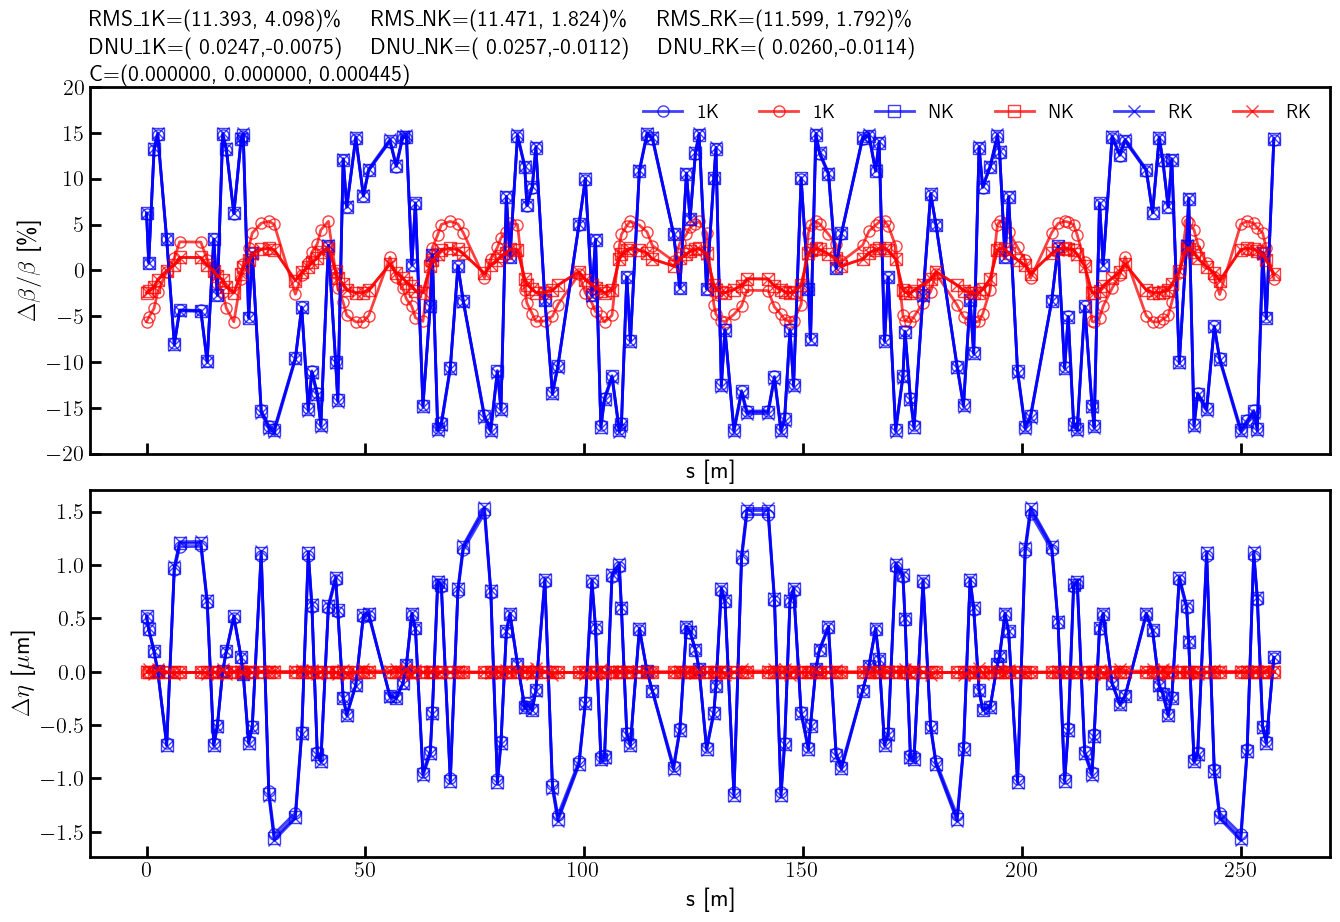

In [50]:
# Beta-beating and dispersion

def rms(x):
    return (x**2).mean().sqrt()

bx_bb_1k = 100.0*(bx - bx_id_1k) / bx
by_bb_1k = 100.0*(by - by_id_1k) / by

bx_bb_nk = 100.0*(bx - bx_id_nk) / bx
by_bb_nk = 100.0*(by - by_id_nk) / by

bx_bb = 100.0*(bx - bx_id) / bx
by_bb = 100.0*(by - by_id) / by

rms_x_1k = rms(bx_bb_1k).item()
ptp_x_1k = (bx_bb_1k.max() - bx_bb_1k.min()).item()
rms_y_1k = rms(by_bb_1k).item()
ptp_y_1k = (by_bb_1k.max() - by_bb_1k.min()).item()

rms_x_nk = rms(bx_bb_nk).item()
ptp_x_nk = (bx_bb_nk.max() - bx_bb_nk.min()).item()
rms_y_nk = rms(by_bb_nk).item()
ptp_y_nk = (by_bb_nk.max() - by_bb_nk.min()).item()

rms_x = rms(bx_bb).item()
ptp_x = (bx_bb.max() - bx_bb.min()).item()
rms_y = rms(by_bb).item()
ptp_y = (by_bb.max() - by_bb.min()).item()

s = ring.locations().cpu().numpy()

bx_np_1k = bx_bb_1k.cpu().numpy()
by_np_1k = by_bb_1k.cpu().numpy()

bx_np_nk = bx_bb_nk.cpu().numpy()
by_np_nk = by_bb_nk.cpu().numpy()

bx_np = bx_bb.cpu().numpy()
by_np = by_bb.cpu().numpy()

etax_1k = etaqx - etaqx_id_1k
etay_1k = etaqy - etaqy_id_1k

etax_nk = etaqx - etaqx_id_nk
etay_nk = etaqy - etaqy_id_nk

etax = etaqx - etaqx_id
etay = etaqy - etaqy_id

rms_etax_1k = rms(etax_1k).item()
ptp_etax_1k = (etax_1k.max() - etax_1k.min()).item()
rms_etay_1k = rms(etay_1k).item()
ptp_etay_1k = (etay_1k.max() - etay_1k.min()).item()

rms_etax_nk = rms(etax_nk).item()
ptp_etax_nk = (etax_nk.max() - etax_nk.min()).item()
rms_etay_nk = rms(etay_nk).item()
ptp_etaf_nk = (etay_nk.max() - etay_nk.min()).item()

rms_etax = rms(etax).item()
ptp_etax = (etax.max() - etax.min()).item()
rms_etay = rms(etay).item()
ptp_etaf = (etay.max() - etay.min()).item()

etax_np_1k = etax_1k.cpu().numpy()
etay_np_1k = etay_1k.cpu().numpy()

etax_np_nk = etax_nk.cpu().numpy()
etay_np_nk = etay_nk.cpu().numpy()

etax_np = etax.cpu().numpy()
etay_np = etay.cpu().numpy()

fig, (ax, ay) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'hspace': 0.1})

ax.errorbar(s, bx_np_1k, fmt='-', marker='o', color='blue', alpha=0.75, lw=2.0, label=r'1K', markerfacecolor='none', ms=8)
ax.errorbar(s, by_np_1k, fmt='-', marker='o', color='red',  alpha=0.75, lw=2.0, label=r'1K', markerfacecolor='none', ms=8)

ax.errorbar(s, bx_np_nk, fmt='-', marker='s', color='blue', alpha=0.75, lw=2.0, label=r'NK', markerfacecolor='none', ms=8)
ax.errorbar(s, by_np_nk, fmt='-', marker='s', color='red',  alpha=0.75, lw=2.0, label=r'NK', markerfacecolor='none', ms=8)

ax.errorbar(s, bx_np, fmt='-', marker='x', color='blue', alpha=0.75, lw=2.0, label=r'RK', ms=8)
ax.errorbar(s, by_np, fmt='-', marker='x', color='red',  alpha=0.75, lw=2.0, label=r'RK', ms=8)

ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')
title = (
    rf'RMS_1K=({rms_x_1k:6.3f},{rms_y_1k:6.3f})\% \quad '
    rf'RMS_NK=({rms_x_nk:6.3f},{rms_y_nk:6.3f})\% \quad '
    rf'RMS_RK=({rms_x:6.3f},{rms_y:6.3f})\% \quad '
)
ax.text(0.0, 1.15, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

title = (
    rf'DNU_1K=({(lambda x: '-' if x < 0 else '~')(nux - nux_id_1k)}{(nux - nux_id_1k).abs().item():05.4f},{(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_1k)}{(nuy - nuy_id_1k).abs().item():05.4f}) \quad '
    rf'DNU_NK=({(lambda x: '-' if x < 0 else '~')(nux - nux_id_nk)}{(nux - nux_id_nk).abs().item():05.4f},{(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_nk)}{(nuy - nuy_id_nk).abs().item():05.4f}) \quad '
    rf'DNU_RK=({(lambda x: '-' if x < 0 else '~')(nux - nux_id)}{(nux - nux_id).abs().item():05.4f},{(lambda x: '-' if x < 0 else '~')(nuy - nuy_id)}{(nuy - nuy_id).abs().item():05.4f}) \quad '
)
ax.text(0.0, 1.075, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

title = (
    rf'\quad C=({c_id_1k.item():.6f}, {c_id_nk.item():.6f}, {c_id.item():.6f})'
)
ax.text(0.0, 1.00, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=6)
ax.set_ylim(-20, 20)

ay.errorbar(s, 10**6*etax_np_1k, fmt='-', marker='o', color='blue', alpha=0.75, lw=2.0, label=r'1K', markerfacecolor='none', ms=8)
ay.errorbar(s, 10**6*etay_np_1k, fmt='-', marker='o', color='red', alpha=0.75, lw=2.0, label=r'1K', markerfacecolor='none', ms=8)

ay.errorbar(s, 10**6*etax_np_nk, fmt='-', marker='s', color='blue', alpha=0.75, lw=2.0, label=r'NK', markerfacecolor='none', ms=8)
ay.errorbar(s, 10**6*etay_np_nk, fmt='-', marker='s', color='red', alpha=0.75, lw=2.0, label=r'NK', markerfacecolor='none', ms=8)

ay.errorbar(s, 10**6*etax_np, fmt='-', marker='x', color='blue', alpha=0.75, lw=2.0, label=r'RK', ms=8)
ay.errorbar(s, 10**6*etay_np, fmt='-', marker='x', color='red', alpha=0.75, lw=2.0, label=r'RK', ms=8)

ay.set_xlabel('s [m]', fontsize=18)
ay.set_ylabel(r'$\Delta \eta$ [$\mu$m]', fontsize=18)
ay.tick_params(width=2, labelsize=16)
ay.tick_params(axis='x', length=8, direction='in')
ay.tick_params(axis='y', length=8, direction='in')


plt.setp(ax.spines.values(), linewidth=2.0)
plt.setp(ay.spines.values(), linewidth=2.0)
plt.show()

### Correction (local & global)

In [51]:
# Set section and corresponding objective jacobian, target values and knob names

section = 'S01'

target = ts_twiss[section]
matrix = ms_twiss[section]

nkn = table_nkn[section]
nks = table_nks[section]

In [52]:
# Insert ID(s)

error = ring.clone()
error.flatten()
error.insert(ID_RK, error.next(f'MLL_{section}').name, position=CENTER*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 745,
 'Dipole': 156,
 'Quadrupole': 360,
 'Corrector': 24,
 'Marker': 24,
 'Matrix': 1}

In [53]:
# Compute tunes (fractional part)

nux_id, nuy_id = tune(error, [], matched=True, limit=1)

In [54]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id, etapx_id, etaqy_id, etapy_id = dispersion(error, orbit, [], limit=1)

In [55]:
# Compute twiss parameters

ax_id, bx_id, ay_id, by_id = twiss(error, [], matched=True, advance=True, full=False).T

In [56]:
# Compute phase advances

mux_id, muy_id = advance(error, [], alignment=False, matched=True).T

In [57]:
# Compute coupling

c_id = coupling(error, [])

In [58]:
# Compute hromaticity

psi_id = chromaticity(error, [])

In [59]:
# Tune shifts

print((nux - nux_id))
print((nuy - nuy_id))

tensor(0.0260, dtype=torch.float64)
tensor(-0.0114, dtype=torch.float64)


In [60]:
# Coupling (minimal tune distance)

print(c)
print(c_id)

tensor(0., dtype=torch.float64)
tensor(0.0004, dtype=torch.float64)


In [61]:
# Chromaticity

print(psi)
print(psi_id)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-72.2873, -66.6489], dtype=torch.float64)


In [62]:
# Define parametric observable vector

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(nqf)*[kf] + len(nqd)*[kd])
    return tune(error, [kn], ('kn', None, nqf + nqd, None), matched=True, limit=1)

def observable_twiss(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    return twiss(error, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), matched=True, advance=True, full=False, convert=False)

def observable_dispersion(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    orbit = torch.tensor(4*[0.0], dtype=dtype)
    etax, _, etay, _ = dispersion(error, orbit, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None))
    return torch.stack([etax, etay]).T

def observable(knobs):
    kn, ks = torch.split(knobs, [6, 4])
    betas = observable_twiss(kn, ks)
    etas = observable_dispersion(kn, ks)
    return torch.cat([betas.flatten(), etas.flatten()])

In [63]:
# Check the residual norm

global_knobs = torch.tensor(2*[0.0], dtype=dtype)
knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

print(((global_observable(global_knobs) - global_target)**2).sum())
print(((observable(knobs) - target)**2).sum())

tensor(0.0008, dtype=torch.float64)
tensor(212.9181, dtype=torch.float64)


In [64]:
# Optimization loop (local)

# Responce matrix (jacobian)

M = matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

# Correction loop

for _ in range(8):
    value = observable(knobs)
    residual = target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    knobs += lr*delta
    print(((value - target)**2).sum())
print()

tensor(212.9181, dtype=torch.float64)
tensor(12.3812, dtype=torch.float64)
tensor(1.0971, dtype=torch.float64)
tensor(0.3043, dtype=torch.float64)
tensor(0.2540, dtype=torch.float64)
tensor(0.2509, dtype=torch.float64)
tensor(0.2507, dtype=torch.float64)
tensor(0.2507, dtype=torch.float64)



In [65]:
# Knob values

kn, ks = torch.split(knobs, [6, 4])

print(kn.numpy())
print(ks.numpy())

[-0.05267976  0.01083084  0.1489824   0.25584477 -0.02073347 -0.06817617]
[-0.00050177 -0.00256234  0.00257823  0.00069695]


In [66]:
# Apply local corrections

error.flatten()

for name, knob in zip(nkn, kn):
    error[name].kn = (error[name].kn + knob).item()

for name, knob in zip(nks, ks):
    error[name].ks = (error[name].ks + knob).item()
    
error.splice()

In [67]:
# Optimization loop (global)

# Responce matrix (jacobian)

M = global_matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

global_knobs = torch.tensor(2*[0.0], dtype=dtype)

# Correction loop

for _ in range(8):
    value = global_observable(global_knobs)
    residual = global_target - value
    if torch.all(residual.abs() < 1.0E-3):
        break    
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    global_knobs += lr*delta
    print(((value - global_target)**2).sum())
print()

tensor(0.0001, dtype=torch.float64)
tensor(9.1701e-06, dtype=torch.float64)



In [68]:
# Knob values

kf, kd = global_knobs

print(kd.numpy())
print(kf.numpy())

0.06194265210737164
-0.02270845314359461


In [69]:
# Apply final corrections

error.flatten()

for name in nqd:
    error[name].kn = (error[name].kn + kd).item()

for name in nqf:
    error[name].kn = (error[name].kn + kf).item()

error.splice()

In [70]:
# Check 

print(((global_observable(0.0*global_knobs) - global_target)**2).sum())
print(((observable(0.0*knobs) - target)**2).sum())

tensor(7.9237e-07, dtype=torch.float64)
tensor(0.3848, dtype=torch.float64)


In [71]:
# Compute tunes (fractional part)

nux_result, nuy_result = tune(error, [], matched=True, limit=1)

In [72]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_result, etapx_result, etaqy_result, etapy_result = dispersion(error, orbit, [], limit=1)

In [73]:
# Compute twiss parameters

ax_result, bx_result, ay_result, by_result = twiss(error, [], matched=True, advance=True, full=False).T

In [74]:
# Compute phase advances

mux_result, muy_result = advance(error, [], alignment=False, matched=True).T

In [75]:
# Compute coupling

c_result = coupling(error, [])

In [76]:
# Compute chromaticity

psi_result = chromaticity(error, [])

In [77]:
# Tune shifts

print((nux - nux_result))
print((nuy - nuy_result))
print()

print((nux - nux_result))
print((nuy - nuy_result))
print()

tensor(-0.0004, dtype=torch.float64)
tensor(-0.0008, dtype=torch.float64)

tensor(-0.0004, dtype=torch.float64)
tensor(-0.0008, dtype=torch.float64)



In [78]:
# Coupling (minimal tune distance)

print(c)
print(c_id)
print(c_result)

tensor(0., dtype=torch.float64)
tensor(0.0004, dtype=torch.float64)
tensor(4.4992e-06, dtype=torch.float64)


In [79]:
# Chromaticity

print(psi)
print(psi_id)
print(psi_result)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-72.2873, -66.6489], dtype=torch.float64)
tensor([-71.1748, -66.7275], dtype=torch.float64)


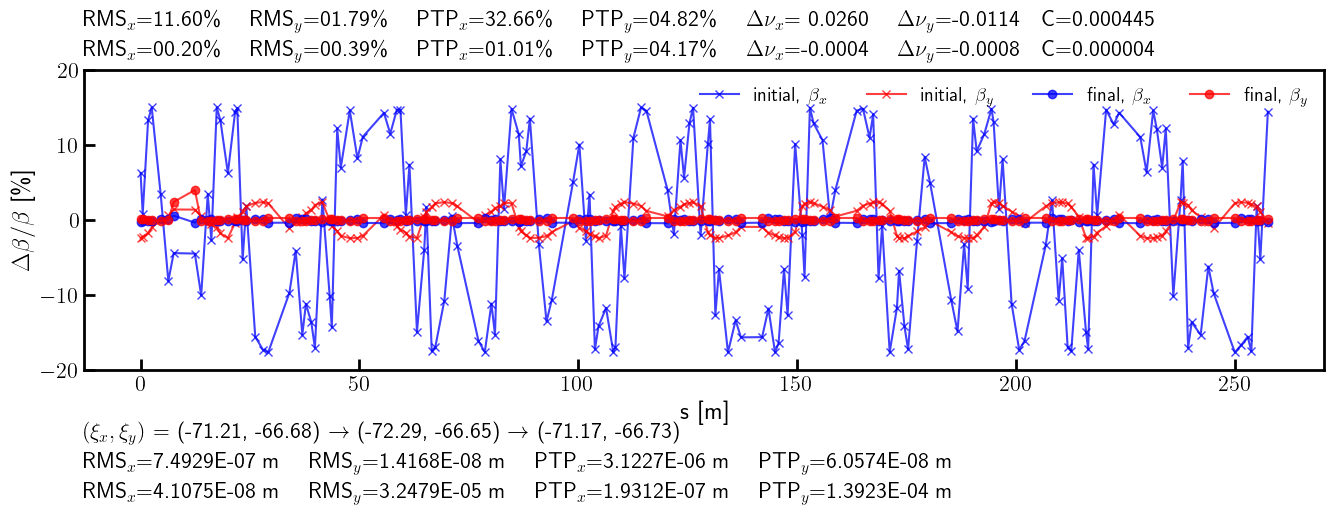

In [80]:
# Beta-beating

(psi_x, psi_y) = psi
(psi_id_x, psi_id_y) = psi_id
(psi_result_x, psi_result_y) =psi_result

bx_ref_bb = 100.0*(bx - bx_id)    / bx
by_ref_bb = 100.0*(by - by_id)    / by
bx_res_bb = 100.0*(bx - bx_result)/ bx
by_res_bb = 100.0*(by - by_result)/ by


def rms(x):
    return (x**2).mean().sqrt()

rms_x_ref = rms(bx_ref_bb).item()
ptp_x_ref = (bx_ref_bb.max() - bx_ref_bb.min()).item()
rms_y_ref = rms(by_ref_bb).item()
ptp_y_ref = (by_ref_bb.max() - by_ref_bb.min()).item()

rms_x_res = rms(bx_res_bb).item()
ptp_x_res = (bx_res_bb.max() - bx_res_bb.min()).item()
rms_y_res = rms(by_res_bb).item()
ptp_y_res = (by_res_bb.max() - by_res_bb.min()).item()

s = ring.locations().cpu().numpy()
bx_ref_np = bx_ref_bb.cpu().numpy()
by_ref_np = by_ref_bb.cpu().numpy()
bx_res_np = bx_res_bb.cpu().numpy()
by_res_np = by_res_bb.cpu().numpy()

etax_ref = etaqx - etaqx_id
etay_ref = etaqy - etaqy_id
etax_res = etaqx - etaqx_result
etay_res = etaqy - etaqy_result

rms_etax_ref = rms(etax_ref).item()
ptp_etax_ref = (etax_ref.max() - etax_ref.min()).item()
rms_etay_ref = rms(etay_ref).item()
ptp_etay_ref = (etay_ref.max() - etay_ref.min()).item()

rms_etax_res = rms(etax_res).item()
ptp_etax_res = (etax_res.max() - etax_res.min()).item()
rms_etay_res = rms(etay_res).item()
ptp_etay_res = (etay_res.max() - etay_res.min()).item()

etax_ref_np = etax_ref.cpu().numpy()
etay_ref_np = etay_ref.cpu().numpy()
etax_res_np = etax_res.cpu().numpy()
etay_res_np = etay_res.cpu().numpy()


fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_ref_np, fmt='-', marker='x', color='blue', alpha=0.75, lw=1.5, label=r'initial, $\beta_x$')
ax.errorbar(s, by_ref_np, fmt='-', marker='x', color='red',  alpha=0.75, lw=1.5, label=r'initial, $\beta_y$')
ax.errorbar(s, bx_res_np, fmt='-', marker='o', color='blue', alpha=0.75, lw=1.5, label=r'final, $\beta_x$')
ax.errorbar(s, by_res_np, fmt='-', marker='o', color='red',  alpha=0.75, lw=1.5, label=r'final, $\beta_y$')
ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')
title = (
    rf'RMS$_x$={rms_x_ref:05.2f}\% \quad RMS$_y$={rms_y_ref:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_ref:05.2f}\% \quad PTP$_y$={ptp_y_ref:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id)}{(nux - nux_id).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id)}{(nuy - nuy_id).abs().item():.4f}'
    rf'\quad C={c_id.item():.6f}'
)
ax.text(0.0, 1.125, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_x_res:05.2f}\% \quad RMS$_y$={rms_y_res:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_res:05.2f}\% \quad PTP$_y$={ptp_y_res:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_result)}{(nux - nux_result).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_result)}{(nuy - nuy_result).abs().item():.4f}'
    rf'\quad C={c_result.item():.6f}'
)
ax.text(0.0, 1.025, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'$(\xi_x, \xi_y)$ = ({psi_x.item():.2f}, {psi_y.item():.2f}) $\to$ ({psi_id_x.item():.2f}, {psi_id_y.item():.2f}) $\to$ ({psi_result_x.item():.2f}, {psi_result_y.item():.2f})' 
)
ax.text(0.0, -0.25 - 0*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_ref:.4E} m \quad RMS$_y$={rms_etay_ref:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_ref:.4E} m \quad PTP$_y$={ptp_etay_ref:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 1*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_res:.4E} m  \quad RMS$_y$={rms_etay_res:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_res:.4E} m  \quad PTP$_y$={ptp_etay_res:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 2*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=4)
ax.set_ylim(-20, 20)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

In [81]:
# Initial and final values

ring.flatten()

kni = {name: ring[name].kn.item() for name in nkn}
ksi = {name: ring[name].ks.item() for name in nks}
kfi = {name: ring[name].kn.item() for name in nqf}
kdi = {name: ring[name].kn.item() for name in nqd}

ring.splice()

error.flatten()

knf = {name: error[name].kn.item() for name in nkn}
ksf = {name: error[name].ks.item() for name in nks}
kff = {name: error[name].kn.item() for name in nqf}
kdf = {name: error[name].kn.item() for name in nqd}

error.splice()

In [82]:
# Global

gkfi = [kfi[name] for name in kfi if name not in nkn]
gkdi = [kdi[name] for name in kdi if name not in nkn]
gkfi, *_ = gkfi
gkdi, *_ = gkdi

gkff = [kff[name] for name in kff if name not in nkn]
gkdf = [kdf[name] for name in kdf if name not in nkn]
gkff, *_ = gkff
gkdf, *_ = gkdf

dkf = [(kff[name] - kfi[name]) for name in kfi if name not in nkn]
dkd = [(kdf[name] - kdi[name]) for name in kdi if name not in nkn]
dkf_abs, *_ = dkf
dkd_abs, *_ = dkd
gk_abs = {'DKF': dkf_abs, 'DKD': dkd_abs}

dkf = [(kff[name]/kfi[name] - 1) for name in kfi if name not in nkn]
dkd = [(kdf[name]/kdi[name] - 1) for name in kdi if name not in nkn]
dkf_fse, *_ = dkf
dkd_fse, *_ = dkd
gk_fse = {'DKF': dkf_fse, 'DKD': dkd_fse}

In [83]:
# Local

dkn_fse = {name: knf[name]/kni[name] - 1 for name in kni}
dkn_abs = {name: knf[name] - kni[name]for name in kni}

dks_fse = {name: 0 for name in ksi}
dks_abs = {name: ksf[name] - ksi[name] for name in ksi}

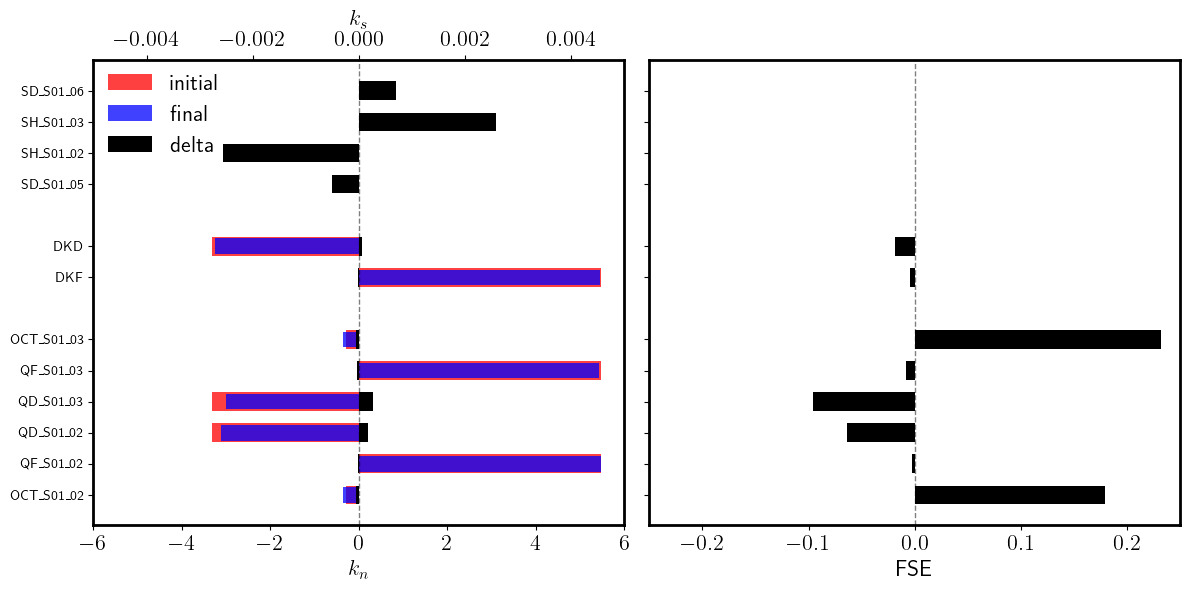

In [84]:
import numpy as np
import matplotlib.pyplot as plt

gap = 1

n_kn = len(dkn_abs)
n_dk = len(gk_abs)
n_ks = len(dks_abs)

y_kn = np.arange(n_kn)
y_dk = np.arange(n_dk) + n_kn + gap
y_ks = np.arange(n_ks) + n_kn + n_dk + 2*gap

yticks = np.concatenate([y_kn, y_dk, y_ks])
yticklabels = [*kni.keys()] + [*gk_abs.keys()] + [*ksi.keys()]

fig, (ax_abs, ax_fse) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

ax_abs.barh(y_dk, [gkfi, gkdi], height=0.6, color='red',   alpha=0.75, label='initial')
ax_abs.barh(y_dk, [gkff, gkdf], height=0.5, color='blue',   alpha=0.75, label='final')
ax_abs.barh(y_dk, [gk_abs['DKF'], gk_abs['DKD']], height=0.6, color='black',   alpha=1, label='delta')

ax_abs.barh(y_kn, kni.values(), height=0.6, color='red',   alpha=0.75)
ax_abs.barh(y_kn, knf.values(), height=0.5, color='blue',   alpha=0.75)
ax_abs.barh(y_kn, list(dkn_abs.values()), height=0.6, color='black', alpha=1)
ax_abs.legend(loc=(0.01, 0.775), frameon=False, fontsize=16, ncol=1)
ax_abs.set_xlim(-6, 6)
ax_abs.set_xlabel(r'$k_n$', fontsize=16)
ax_abs.tick_params(axis='x', labelsize=16)
ax_abs = ax_abs.twiny()
ax_abs.barh(y_ks, ksi.values(), height=0.6, color='red',   alpha=0.75)
ax_abs.barh(y_ks, ksf.values(), height=0.5, color='blue',   alpha=0.75)
ax_abs.barh(y_ks, list(dks_abs.values()), height=0.6, color='black', alpha=1)
ax_abs.set_xlim(-0.005, 0.005)
ax_abs.set_yticks(yticks)
ax_abs.set_yticklabels(yticklabels, fontsize=16)
ax_abs.axvline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax_abs.set_xlabel(r'$k_s$', fontsize=16)
ax_abs.tick_params(axis='x', labelsize=16)
ax_abs.tick_params(axis='y', labelsize=16)

ax_fse.barh(y_dk, gk_fse.values(), height=0.6, color='black',  alpha=1)
ax_fse.barh(y_kn, dkn_fse.values(), height=0.6, color='black',   alpha=1)
ax_fse.set_xlim(-25/100, 25/100)
ax_fse.axvline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax_fse.set_xlabel(r'FSE', fontsize=16)
ax_fse.tick_params(axis='x', labelsize=16)
ax_fse.tick_params(axis='y', labelsize=16)

plt.setp(ax_abs.spines.values(), linewidth=2.0)
plt.setp(ax_fse.spines.values(), linewidth=2.0)

plt.tight_layout()
plt.show()

### Correction (local)

In [85]:
# Set section and corresponding objective jacobian, target values and knob names

section = 'S01'

target = ts_orbit[section]
matrix = ms_orbit[section]

nkn = table_nkn[section]
nks = table_nks[section]

In [86]:
# Insert ID(s)

error = ring.clone()
error.flatten()
error.insert(ID_RK, error.next(f'MLL_{section}').name, position=CENTER*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 745,
 'Dipole': 156,
 'Quadrupole': 360,
 'Corrector': 24,
 'Marker': 24,
 'Matrix': 1}

In [87]:
# Compute tunes (fractional part)

nux_id, nuy_id = tune(error, [], matched=True, limit=1)

In [88]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id, etapx_id, etaqy_id, etapy_id = dispersion(error, orbit, [], limit=1)

In [89]:
# Compute twiss parameters

ax_id, bx_id, ay_id, by_id = twiss(error, [], matched=True, advance=True, full=False).T

In [90]:
# Compute phase advances

mux_id, muy_id = advance(error, [], alignment=False, matched=True).T

In [91]:
# Compute coupling

c_id = coupling(error, [])

In [92]:
# Compute hromaticity

psi_id = chromaticity(error, [])

In [93]:
# Tune shifts

print((nux - nux_id))
print((nuy - nuy_id))

tensor(0.0260, dtype=torch.float64)
tensor(-0.0114, dtype=torch.float64)


In [94]:
# Coupling (minimal tune distance)

print(c)
print(c_id)

tensor(0., dtype=torch.float64)
tensor(0.0004, dtype=torch.float64)


In [95]:
# Chromaticity

print(psi)
print(psi_id)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-72.2873, -66.6489], dtype=torch.float64)


In [96]:
# Define parametric observable vector

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(nqf)*[kf] + len(nqd)*[kd])
    return tune(error, [kn], ('kn', None, nqf + nqd, None), matched=True, limit=1)

def observable_orm(kn, ks, nkn, nks):  
    orm = ORM(error, orbit,  [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), limit=1)
    return orm

def observable(knobs):
    kn, ks = torch.split(knobs, [6, 4])  
    orm = observable_orm(kn, ks, nkn, nks)
    return orm.flatten()

In [97]:
# Check the residual norm

global_knobs = torch.tensor(2*[0.0], dtype=dtype)
knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

print(((global_observable(global_knobs) - global_target)**2).sum())
print(((observable(knobs) - target)**2).sum())

tensor(0.0008, dtype=torch.float64)
tensor(1498.9240, dtype=torch.float64)


In [98]:
# Optimization loop (local)

# Responce matrix (jacobian)

M = matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

# Correction loop

for _ in range(8):
    value = observable(knobs)
    residual = target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    knobs += lr*delta
    print(((value - target)**2).sum())
print()

tensor(1498.9240, dtype=torch.float64)
tensor(94.4720, dtype=torch.float64)
tensor(27.3701, dtype=torch.float64)
tensor(14.5888, dtype=torch.float64)
tensor(11.7572, dtype=torch.float64)
tensor(11.2675, dtype=torch.float64)
tensor(11.2024, dtype=torch.float64)
tensor(11.1966, dtype=torch.float64)



In [99]:
# Knob values

kn, ks = torch.split(knobs, [6, 4])

print(kn.numpy())
print(ks.numpy())

[-0.03471056 -0.22054716  0.76101755  0.74900005 -0.21673683 -0.03342773]
[-0.00037728 -0.0024463   0.00244978  0.00049938]


In [100]:
# Apply local corrections

error.flatten()

for name, knob in zip(nkn, kn):
    error[name].kn = (error[name].kn + knob).item()

for name, knob in zip(nks, ks):
    error[name].ks = (error[name].ks + knob).item()
    
error.splice()

In [101]:
# Optimization loop (global)

# Responce matrix (jacobian)

M = global_matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

global_knobs = torch.tensor(2*[0.0], dtype=dtype)

# Correction loop

for _ in range(8):
    value = global_observable(global_knobs)
    residual = global_target - value
    if torch.all(residual.abs() < 1.0E-3):
        break    
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    global_knobs += lr*delta
    print(((value - global_target)**2).sum())
print()

In [102]:
# Knob values

kf, kd = global_knobs

print(kd.numpy())
print(kf.numpy())

0.0
0.0


In [103]:
# Apply final corrections

error.flatten()

for name in nqd:
    error[name].kn = (error[name].kn + kd).item()

for name in nqf:
    error[name].kn = (error[name].kn + kf).item()

error.splice()

In [104]:
# Check 

print(((global_observable(0.0*global_knobs) - global_target)**2).sum())
print(((observable(0.0*knobs) - target)**2).sum())

tensor(1.1095e-07, dtype=torch.float64)
tensor(11.1968, dtype=torch.float64)


In [105]:
# Compute tunes (fractional part)

nux_result, nuy_result = tune(error, [], matched=True, limit=1)

In [106]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_result, etapx_result, etaqy_result, etapy_result = dispersion(error, orbit, [], limit=1)

In [107]:
# Compute twiss parameters

ax_result, bx_result, ay_result, by_result = twiss(error, [], matched=True, advance=True, full=False).T

In [108]:
# Compute phase advances

mux_result, muy_result = advance(error, [], alignment=False, matched=True).T

In [109]:
# Compute coupling

c_result = coupling(error, [])

In [110]:
# Compute chromaticity

psi_result = chromaticity(error, [])

In [111]:
# Tune shifts

print((nux - nux_result))
print((nuy - nuy_result))
print()

print((nux - nux_result))
print((nuy - nuy_result))
print()

tensor(0.0003, dtype=torch.float64)
tensor(0.0002, dtype=torch.float64)

tensor(0.0003, dtype=torch.float64)
tensor(0.0002, dtype=torch.float64)



In [112]:
# Coupling (minimal tune distance)

print(c)
print(c_id)
print(c_result)

tensor(0., dtype=torch.float64)
tensor(0.0004, dtype=torch.float64)
tensor(4.1525e-06, dtype=torch.float64)


In [113]:
# Chromaticity

print(psi)
print(psi_id)
print(psi_result)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-72.2873, -66.6489], dtype=torch.float64)
tensor([-71.1939, -66.6599], dtype=torch.float64)


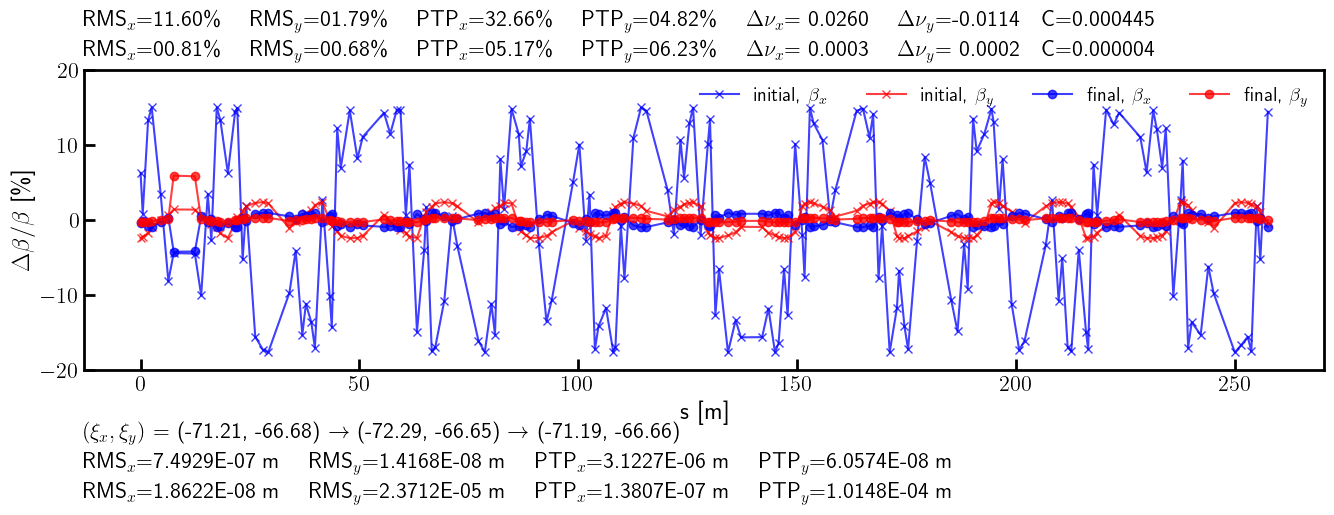

In [114]:
# Beta-beating

(psi_x, psi_y) = psi
(psi_id_x, psi_id_y) = psi_id
(psi_result_x, psi_result_y) =psi_result

bx_ref_bb = 100.0*(bx - bx_id)    / bx
by_ref_bb = 100.0*(by - by_id)    / by
bx_res_bb = 100.0*(bx - bx_result)/ bx
by_res_bb = 100.0*(by - by_result)/ by


def rms(x):
    return (x**2).mean().sqrt()

rms_x_ref = rms(bx_ref_bb).item()
ptp_x_ref = (bx_ref_bb.max() - bx_ref_bb.min()).item()
rms_y_ref = rms(by_ref_bb).item()
ptp_y_ref = (by_ref_bb.max() - by_ref_bb.min()).item()

rms_x_res = rms(bx_res_bb).item()
ptp_x_res = (bx_res_bb.max() - bx_res_bb.min()).item()
rms_y_res = rms(by_res_bb).item()
ptp_y_res = (by_res_bb.max() - by_res_bb.min()).item()

s = ring.locations().cpu().numpy()
bx_ref_np = bx_ref_bb.cpu().numpy()
by_ref_np = by_ref_bb.cpu().numpy()
bx_res_np = bx_res_bb.cpu().numpy()
by_res_np = by_res_bb.cpu().numpy()

etax_ref = etaqx - etaqx_id
etay_ref = etaqy - etaqy_id
etax_res = etaqx - etaqx_result
etay_res = etaqy - etaqy_result

rms_etax_ref = rms(etax_ref).item()
ptp_etax_ref = (etax_ref.max() - etax_ref.min()).item()
rms_etay_ref = rms(etay_ref).item()
ptp_etay_ref = (etay_ref.max() - etay_ref.min()).item()

rms_etax_res = rms(etax_res).item()
ptp_etax_res = (etax_res.max() - etax_res.min()).item()
rms_etay_res = rms(etay_res).item()
ptp_etay_res = (etay_res.max() - etay_res.min()).item()

etax_ref_np = etax_ref.cpu().numpy()
etay_ref_np = etay_ref.cpu().numpy()
etax_res_np = etax_res.cpu().numpy()
etay_res_np = etay_res.cpu().numpy()


fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_ref_np, fmt='-', marker='x', color='blue', alpha=0.75, lw=1.5, label=r'initial, $\beta_x$')
ax.errorbar(s, by_ref_np, fmt='-', marker='x', color='red',  alpha=0.75, lw=1.5, label=r'initial, $\beta_y$')
ax.errorbar(s, bx_res_np, fmt='-', marker='o', color='blue', alpha=0.75, lw=1.5, label=r'final, $\beta_x$')
ax.errorbar(s, by_res_np, fmt='-', marker='o', color='red',  alpha=0.75, lw=1.5, label=r'final, $\beta_y$')
ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')
title = (
    rf'RMS$_x$={rms_x_ref:05.2f}\% \quad RMS$_y$={rms_y_ref:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_ref:05.2f}\% \quad PTP$_y$={ptp_y_ref:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id)}{(nux - nux_id).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id)}{(nuy - nuy_id).abs().item():.4f}'
    rf'\quad C={c_id.item():.6f}'
)
ax.text(0.0, 1.125, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_x_res:05.2f}\% \quad RMS$_y$={rms_y_res:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_res:05.2f}\% \quad PTP$_y$={ptp_y_res:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_result)}{(nux - nux_result).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_result)}{(nuy - nuy_result).abs().item():.4f}'
    rf'\quad C={c_result.item():.6f}'
)
ax.text(0.0, 1.025, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'$(\xi_x, \xi_y)$ = ({psi_x.item():.2f}, {psi_y.item():.2f}) $\to$ ({psi_id_x.item():.2f}, {psi_id_y.item():.2f}) $\to$ ({psi_result_x.item():.2f}, {psi_result_y.item():.2f})' 
)
ax.text(0.0, -0.25 - 0*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_ref:.4E} m \quad RMS$_y$={rms_etay_ref:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_ref:.4E} m \quad PTP$_y$={ptp_etay_ref:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 1*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
title = (
    rf'RMS$_x$={rms_etax_res:.4E} m  \quad RMS$_y$={rms_etay_res:.4E} m  \quad '
    rf'PTP$_x$={ptp_etax_res:.4E} m  \quad PTP$_y$={ptp_etay_res:.4E} m  \quad '
)
ax.text(0.0, -0.25 - 2*0.1, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=4)
ax.set_ylim(-20, 20)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

In [115]:
# Initial and final values

ring.flatten()

kni = {name: ring[name].kn.item() for name in nkn}
ksi = {name: ring[name].ks.item() for name in nks}
kfi = {name: ring[name].kn.item() for name in nqf}
kdi = {name: ring[name].kn.item() for name in nqd}

ring.splice()

error.flatten()

knf = {name: error[name].kn.item() for name in nkn}
ksf = {name: error[name].ks.item() for name in nks}
kff = {name: error[name].kn.item() for name in nqf}
kdf = {name: error[name].kn.item() for name in nqd}

error.splice()

In [116]:
# Global

gkfi = [kfi[name] for name in kfi if name not in nkn]
gkdi = [kdi[name] for name in kdi if name not in nkn]
gkfi, *_ = gkfi
gkdi, *_ = gkdi

gkff = [kff[name] for name in kff if name not in nkn]
gkdf = [kdf[name] for name in kdf if name not in nkn]
gkff, *_ = gkff
gkdf, *_ = gkdf

dkf = [(kff[name] - kfi[name]) for name in kfi if name not in nkn]
dkd = [(kdf[name] - kdi[name]) for name in kdi if name not in nkn]
dkf_abs, *_ = dkf
dkd_abs, *_ = dkd
gk_abs = {'DKF': dkf_abs, 'DKD': dkd_abs}

dkf = [(kff[name]/kfi[name] - 1) for name in kfi if name not in nkn]
dkd = [(kdf[name]/kdi[name] - 1) for name in kdi if name not in nkn]
dkf_fse, *_ = dkf
dkd_fse, *_ = dkd
gk_fse = {'DKF': dkf_fse, 'DKD': dkd_fse}

In [117]:
# Local

dkn_fse = {name: knf[name]/kni[name] - 1 for name in kni}
dkn_abs = {name: knf[name] - kni[name]for name in kni}

dks_fse = {name: 0 for name in ksi}
dks_abs = {name: ksf[name] - ksi[name] for name in ksi}

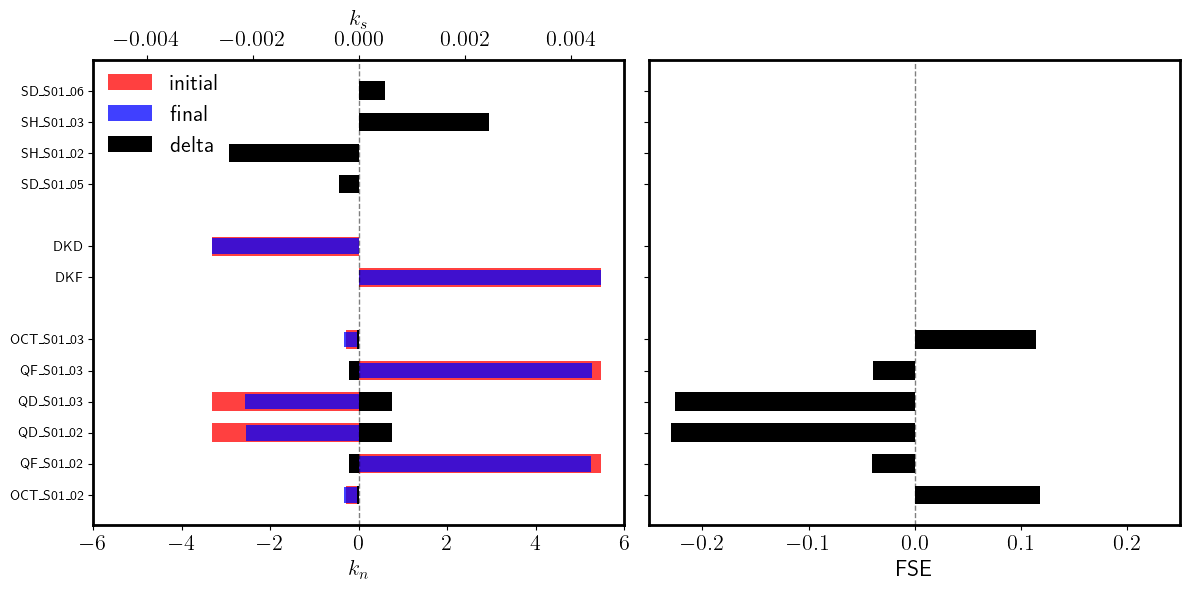

In [118]:
import numpy as np
import matplotlib.pyplot as plt

gap = 1

n_kn = len(dkn_abs)
n_dk = len(gk_abs)
n_ks = len(dks_abs)

y_kn = np.arange(n_kn)
y_dk = np.arange(n_dk) + n_kn + gap
y_ks = np.arange(n_ks) + n_kn + n_dk + 2*gap

yticks = np.concatenate([y_kn, y_dk, y_ks])
yticklabels = [*kni.keys()] + [*gk_abs.keys()] + [*ksi.keys()]

fig, (ax_abs, ax_fse) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

ax_abs.barh(y_dk, [gkfi, gkdi], height=0.6, color='red',   alpha=0.75, label='initial')
ax_abs.barh(y_dk, [gkff, gkdf], height=0.5, color='blue',   alpha=0.75, label='final')
ax_abs.barh(y_dk, [gk_abs['DKF'], gk_abs['DKD']], height=0.6, color='black',   alpha=1, label='delta')

ax_abs.barh(y_kn, kni.values(), height=0.6, color='red',   alpha=0.75)
ax_abs.barh(y_kn, knf.values(), height=0.5, color='blue',   alpha=0.75)
ax_abs.barh(y_kn, list(dkn_abs.values()), height=0.6, color='black', alpha=1)
ax_abs.legend(loc=(0.01, 0.775), frameon=False, fontsize=16, ncol=1)
ax_abs.set_xlim(-6, 6)
ax_abs.set_xlabel(r'$k_n$', fontsize=16)
ax_abs.tick_params(axis='x', labelsize=16)
ax_abs = ax_abs.twiny()
ax_abs.barh(y_ks, ksi.values(), height=0.6, color='red',   alpha=0.75)
ax_abs.barh(y_ks, ksf.values(), height=0.5, color='blue',   alpha=0.75)
ax_abs.barh(y_ks, list(dks_abs.values()), height=0.6, color='black', alpha=1)
ax_abs.set_xlim(-0.005, 0.005)
ax_abs.set_yticks(yticks)
ax_abs.set_yticklabels(yticklabels, fontsize=16)
ax_abs.axvline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax_abs.set_xlabel(r'$k_s$', fontsize=16)
ax_abs.tick_params(axis='x', labelsize=16)
ax_abs.tick_params(axis='y', labelsize=16)

ax_fse.barh(y_dk, gk_fse.values(), height=0.6, color='black',  alpha=1)
ax_fse.barh(y_kn, dkn_fse.values(), height=0.6, color='black',   alpha=1)
ax_fse.set_xlim(-25/100, 25/100)
ax_fse.axvline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax_fse.set_xlabel(r'FSE', fontsize=16)
ax_fse.tick_params(axis='x', labelsize=16)
ax_fse.tick_params(axis='y', labelsize=16)

plt.setp(ax_abs.spines.values(), linewidth=2.0)
plt.setp(ax_fse.spines.values(), linewidth=2.0)

plt.tight_layout()
plt.show()